<a href="https://colab.research.google.com/github/kohmex/fantastic-engine/blob/main/Capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import kagglehub
path = kagglehub.dataset_download("patelris/crop-yield-prediction-dataset")

In [ ]:
import os
import pandas as pd

# List files in the downloaded dataset directory
print(f"Files in {path}:")
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Files in /root/.cache/kagglehub/datasets/patelris/crop-yield-prediction-dataset/versions/7:
/root/.cache/kagglehub/datasets/patelris/crop-yield-prediction-dataset/versions/7/rainfall.csv
/root/.cache/kagglehub/datasets/patelris/crop-yield-prediction-dataset/versions/7/yield.csv
/root/.cache/kagglehub/datasets/patelris/crop-yield-prediction-dataset/versions/7/yield_df.csv
/root/.cache/kagglehub/datasets/patelris/crop-yield-prediction-dataset/versions/7/pesticides.csv
/root/.cache/kagglehub/datasets/patelris/crop-yield-prediction-dataset/versions/7/temp.csv


Based on the file listing, I'll load the `yield.csv`, `rainfall.csv`, `pesticides.csv`, and `temp.csv` files into pandas DataFrames.

In [ ]:
yield_df = pd.read_csv(os.path.join(path, 'yield.csv'))
rainfall_df = pd.read_csv(os.path.join(path, 'rainfall.csv'))
pesticides_df = pd.read_csv(os.path.join(path, 'pesticides.csv'))
temp_df = pd.read_csv(os.path.join(path, 'temp.csv'))

print("\nYield DataFrame head:")
display(yield_df.head())

print("\nRainfall DataFrame head:")
display(rainfall_df.head())

print("\nPesticides DataFrame head:")
display(pesticides_df.head())

print("\nTemperature DataFrame head:")
display(temp_df.head())


Yield DataFrame head:


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400



Rainfall DataFrame head:


,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327



Pesticides DataFrame head:


,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0



Temperature DataFrame head:


,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN


Now that the dataframes are loaded, I will inspect their data types and check for missing values to understand the data's structure and quality.

In [ ]:
print("\n--- Yield DataFrame Info ---")
yield_df.info()
print("\n--- Yield DataFrame Missing Values ---")
print(yield_df.isnull().sum())

print("\n--- Rainfall DataFrame Info ---")
rainfall_df.info()
print("\n--- Rainfall DataFrame Missing Values ---")
print(rainfall_df.isnull().sum())

print("\n--- Pesticides DataFrame Info ---")
pesticides_df.info()
print("\n--- Pesticides DataFrame Missing Values ---")
print(pesticides_df.isnull().sum())

print("\n--- Temperature DataFrame Info ---")
temp_df.info()
print("\n--- Temperature DataFrame Missing Values ---")
print(temp_df.isnull().sum())


--- Yield DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56717 entries, 0 to 56716
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Domain Code   56717 non-null  object
 1   Domain        56717 non-null  object
 2   Area Code     56717 non-null  int64 
 3   Area          56717 non-null  object
 4   Element Code  56717 non-null  int64 
 5   Element       56717 non-null  object
 6   Item Code     56717 non-null  int64 
 7   Item          56717 non-null  object
 8   Year Code     56717 non-null  int64 
 9   Year          56717 non-null  int64 
 10  Unit          56717 non-null  object
 11  Value         56717 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 5.2+ MB

--- Yield DataFrame Missing Values ---
Domain Code     0
Domain          0
Area Code       0
Area            0
Element Code    0
Element         0
Item Code       0
Item            0
Year Code       0
Year            0
Uni

Based on the data inspection, I will now clean the column names, handle missing values, and simplify the `yield_df` by dropping irrelevant columns.

In [ ]:
# Clean column names
rainfall_df.rename(columns={' Area': 'Area'}, inplace=True)
temp_df.rename(columns={'country': 'Area'}, inplace=True)

# Convert 'average_rain_fall_mm_per_year' to numeric, coercing errors
rainfall_df['average_rain_fall_mm_per_year'] = pd.to_numeric(rainfall_df['average_rain_fall_mm_per_year'], errors='coerce')

# Impute missing values with the mean
rainfall_df['average_rain_fall_mm_per_year'].fillna(rainfall_df['average_rain_fall_mm_per_year'].mean(), inplace=True)
temp_df['avg_temp'].fillna(temp_df['avg_temp'].mean(), inplace=True)

# Drop irrelevant columns from yield_df
yield_df.drop(columns=['Domain Code', 'Domain', 'Area Code', 'Element Code', 'Element', 'Item Code', 'Unit', 'Year Code'], inplace=True)

print("\n--- Cleaned Rainfall DataFrame Info ---")
rainfall_df.info()
print("\n--- Cleaned Rainfall DataFrame Missing Values ---")
print(rainfall_df.isnull().sum())

print("\n--- Cleaned Temperature DataFrame Info ---")
temp_df.info()
print("\n--- Cleaned Temperature DataFrame Missing Values ---")
print(temp_df.isnull().sum())

print("\n--- Simplified Yield DataFrame head ---")
display(yield_df.head())


--- Cleaned Rainfall DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6727 entries, 0 to 6726
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           6727 non-null   object 
 1   Year                           6727 non-null   int64  
 2   average_rain_fall_mm_per_year  6727 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 157.8+ KB

--- Cleaned Rainfall DataFrame Missing Values ---
Area                             0
Year                             0
average_rain_fall_mm_per_year    0
dtype: int64

--- Cleaned Temperature DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71311 entries, 0 to 71310
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      71311 non-null  int64  
 1   Area      71311 non-null  object 
 2   avg_tem

/tmp/ipykernel_1349/3963924598.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  rainfall_df['average_rain_fall_mm_per_year'].fillna(rainfall_df['average_rain_fall_mm_per_year'].mean(), inplace=True)
/tmp/ipykernel_1349/3963924598.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

,Area,Item,Year,Value
0,Afghanistan,Maize,1961,14000
1,Afghanistan,Maize,1962,14000
2,Afghanistan,Maize,1963,14260
3,Afghanistan,Maize,1964,14257
4,Afghanistan,Maize,1965,14400


Now that the individual dataframes have been cleaned, I will merge them into a single dataframe based on common columns ('Area' and 'Year') to create a comprehensive dataset for crop yield prediction.

In [ ]:
# Merge yield_df with rainfall_df
merged_df = pd.merge(yield_df, rainfall_df, on=['Year', 'Area'], how='left')

# Merge the result with pesticides_df
merged_df = pd.merge(merged_df, pesticides_df, on=['Year', 'Area'], how='left')

# Merge the result with temp_df
# Note: 'year' in temp_df needs to be 'Year' to match other DFs
temp_df.rename(columns={'year': 'Year'}, inplace=True)
merged_df = pd.merge(merged_df, temp_df, on=['Year', 'Area'], how='left')

print("\n--- Merged DataFrame Head ---")
display(merged_df.head())

print("\n--- Merged DataFrame Info ---")
merged_df.info()

print("\n--- Merged DataFrame Missing Values after initial merge ---")
print(merged_df.isnull().sum())


--- Merged DataFrame Head ---


,Area,Item_x,Year,Value_x,average_rain_fall_mm_per_year,Domain,Element,Item_y,Unit,Value_y,avg_temp
0,Afghanistan,Maize,1961,14000,NaN,NaN,NaN,NaN,NaN,NaN,14.23
1,Afghanistan,Maize,1962,14000,NaN,NaN,NaN,NaN,NaN,NaN,14.10
2,Afghanistan,Maize,1963,14260,NaN,NaN,NaN,NaN,NaN,NaN,15.01
3,Afghanistan,Maize,1964,14257,NaN,NaN,NaN,NaN,NaN,NaN,13.73
4,Afghanistan,Maize,1965,14400,NaN,NaN,NaN,NaN,NaN,NaN,13.90



--- Merged DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109366 entries, 0 to 109365
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Area                           109366 non-null  object 
 1   Item_x                         109366 non-null  object 
 2   Year                           109366 non-null  int64  
 3   Value_x                        109366 non-null  int64  
 4   average_rain_fall_mm_per_year  53070 non-null   float64
 5   Domain                         39918 non-null   object 
 6   Element                        39918 non-null   object 
 7   Item_y                         39918 non-null   object 
 8   Unit                           39918 non-null   object 
 9   Value_y                        39918 non-null   float64
 10  avg_temp                       84859 non-null   float64
dtypes: float64(3), int64(2), object(6)
memory usage: 9.2+ MB

--

Addressing missing values and renaming columns to prepare the merged dataset for modeling.

In [ ]:
# Rename columns for clarity
merged_df.rename(columns={'Item_x': 'Crop', 'Value_x': 'Yield'}, inplace=True)

# Impute missing numerical values with the mean
merged_df['average_rain_fall_mm_per_year'].fillna(merged_df['average_rain_fall_mm_per_year'].mean(), inplace=True)
merged_df['avg_temp'].fillna(merged_df['avg_temp'].mean(), inplace=True)
merged_df['Value_y'].fillna(merged_df['Value_y'].mean(), inplace=True)

# Drop redundant pesticide categorical columns
merged_df.drop(columns=['Domain', 'Element', 'Item_y', 'Unit'], inplace=True)

print("\n--- Final Merged DataFrame Head ---")
display(merged_df.head())

print("\n--- Final Merged DataFrame Info ---")
merged_df.info()

print("\n--- Final Merged DataFrame Missing Values ---")
print(merged_df.isnull().sum())


--- Final Merged DataFrame Head ---


/tmp/ipykernel_1349/2919811652.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['average_rain_fall_mm_per_year'].fillna(merged_df['average_rain_fall_mm_per_year'].mean(), inplace=True)
/tmp/ipykernel_1349/2919811652.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

,Area,Crop,Year,Yield,average_rain_fall_mm_per_year,Value_y,avg_temp
0,Afghanistan,Maize,1961,14000,1142.832563,38414.593847,14.23
1,Afghanistan,Maize,1962,14000,1142.832563,38414.593847,14.10
2,Afghanistan,Maize,1963,14260,1142.832563,38414.593847,15.01
3,Afghanistan,Maize,1964,14257,1142.832563,38414.593847,13.73
4,Afghanistan,Maize,1965,14400,1142.832563,38414.593847,13.90



--- Final Merged DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109366 entries, 0 to 109365
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Area                           109366 non-null  object 
 1   Crop                           109366 non-null  object 
 2   Year                           109366 non-null  int64  
 3   Yield                          109366 non-null  int64  
 4   average_rain_fall_mm_per_year  109366 non-null  float64
 5   Value_y                        109366 non-null  float64
 6   avg_temp                       109366 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 5.8+ MB

--- Final Merged DataFrame Missing Values ---
Area                             0
Crop                             0
Year                             0
Yield                            0
average_rain_fall_mm_per_year    0
Value_y             

Now that the data is cleaned and merged, I will perform categorical encoding on 'Area' and 'Crop' features, and then split the dataset into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Filter the dataset for Nigeria only
nigeria_df = merged_df[merged_df['Area'] == 'Nigeria']

# Define features (X) and target (y) using the filtered DataFrame
X = nigeria_df.drop('Yield', axis=1)
y = nigeria_df['Yield']

# Identify categorical and numerical columns
# 'Area' is no longer a categorical feature for encoding as it's now a single value
categorical_features = ['Crop']
numerical_features = ['Year', 'average_rain_fall_mm_per_year', 'Value_y', 'avg_temp']

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Apply the preprocessor to the training data to see the resulting feature names
# X_train_processed_df = pd.DataFrame(preprocessor.fit_transform(X_train))
# print("\nFirst 5 rows of processed X_train (after one-hot encoding):")
# display(X_train_processed_df.head())


X_train shape: (2992, 6)
X_test shape: (748, 6)
y_train shape: (2992,)
y_test shape: (748,)


With the data preprocessed and split, I will now train a RandomForestRegressor model and evaluate its performance.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create a pipeline that first preprocesses the data and then trains a RandomForestRegressor
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Train the model
print("Training the RandomForestRegressor model...")
model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Training the RandomForestRegressor model...
Model training complete.

Mean Absolute Error (MAE): 290.07
Mean Squared Error (MSE): 672548.30
R-squared (R2): 1.00


### Visualizing Actual vs. Predicted Yields

To visually inspect the model's performance, let's create a scatter plot comparing the actual `y_test` values with the `y_pred` values from our `RandomForestRegressor`.

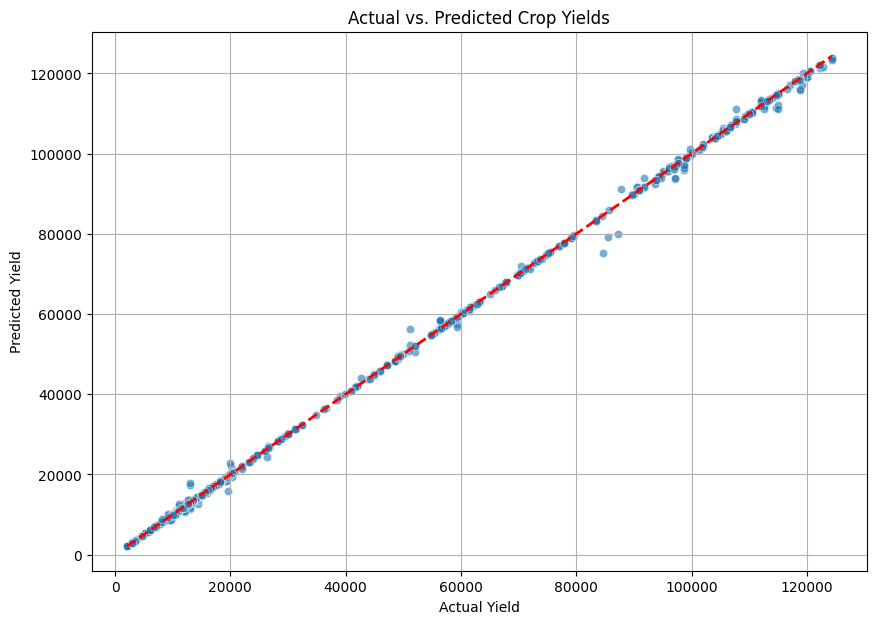

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Plot a diagonal line
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Actual vs. Predicted Crop Yields')
plt.grid(True)
plt.show()

### Feature Importance Analysis

Understanding feature importance helps us identify which input variables have the most significant impact on the predicted crop yield. For a `RandomForestRegressor`, this information can be extracted directly from the trained model.

In [ ]:
import numpy as np

# Get the feature names after one-hot encoding
onehot_features = model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combine all feature names
all_features = np.concatenate([onehot_features, numerical_features])

# Get feature importances from the trained RandomForestRegressor model
feature_importances = model.named_steps['regressor'].feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n--- Feature Importances ---")
display(importance_df.head(10)) # Display top 10 features


--- Feature Importances ---


,Feature,Importance
0,Crop_Cassava,0.237817
9,Crop_Yams,0.230196
10,Year,0.176746
2,Crop_Plantains and others,0.122783
3,Crop_Potatoes,0.112852
7,Crop_Sweet potatoes,0.111526
6,Crop_Soybeans,0.004541
5,Crop_Sorghum,0.001464
1,Crop_Maize,0.000798
13,avg_temp,0.000380


/tmp/ipykernel_1349/1014977467.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis') # Top 15 features


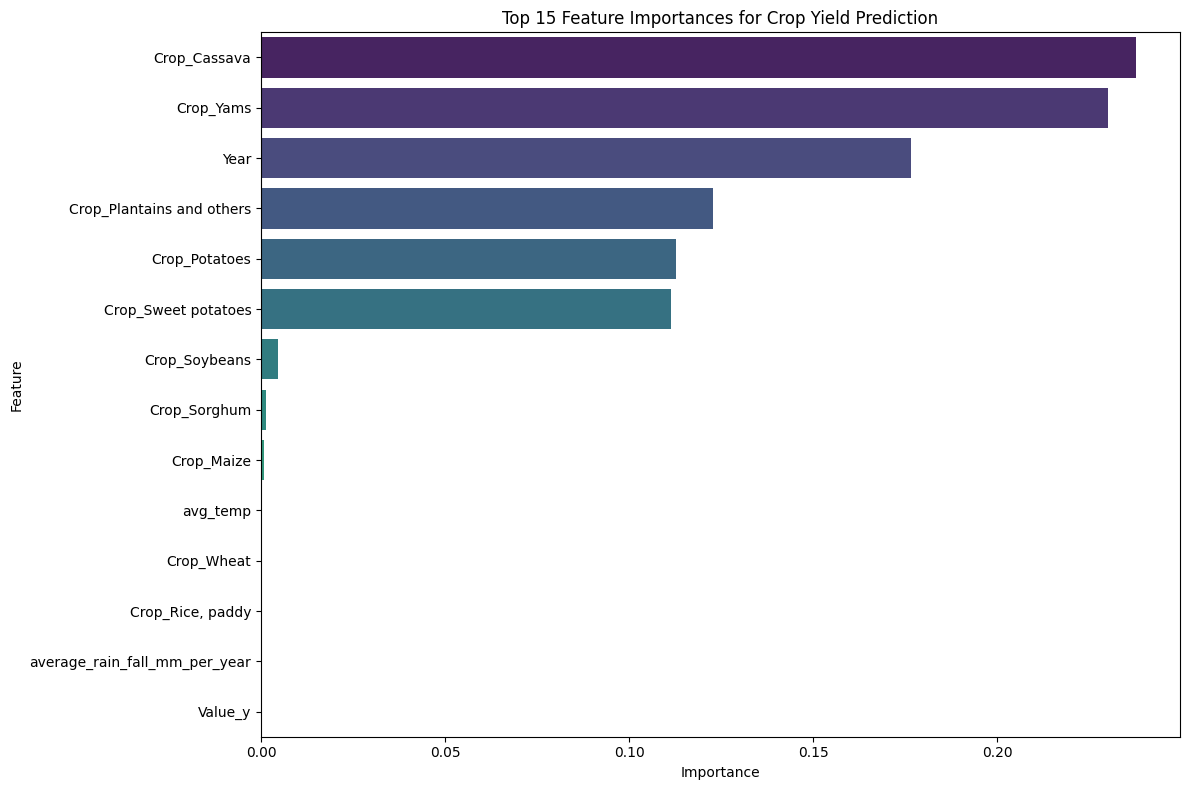

In [ ]:
# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis') # Top 15 features
plt.title('Top 15 Feature Importances for Crop Yield Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

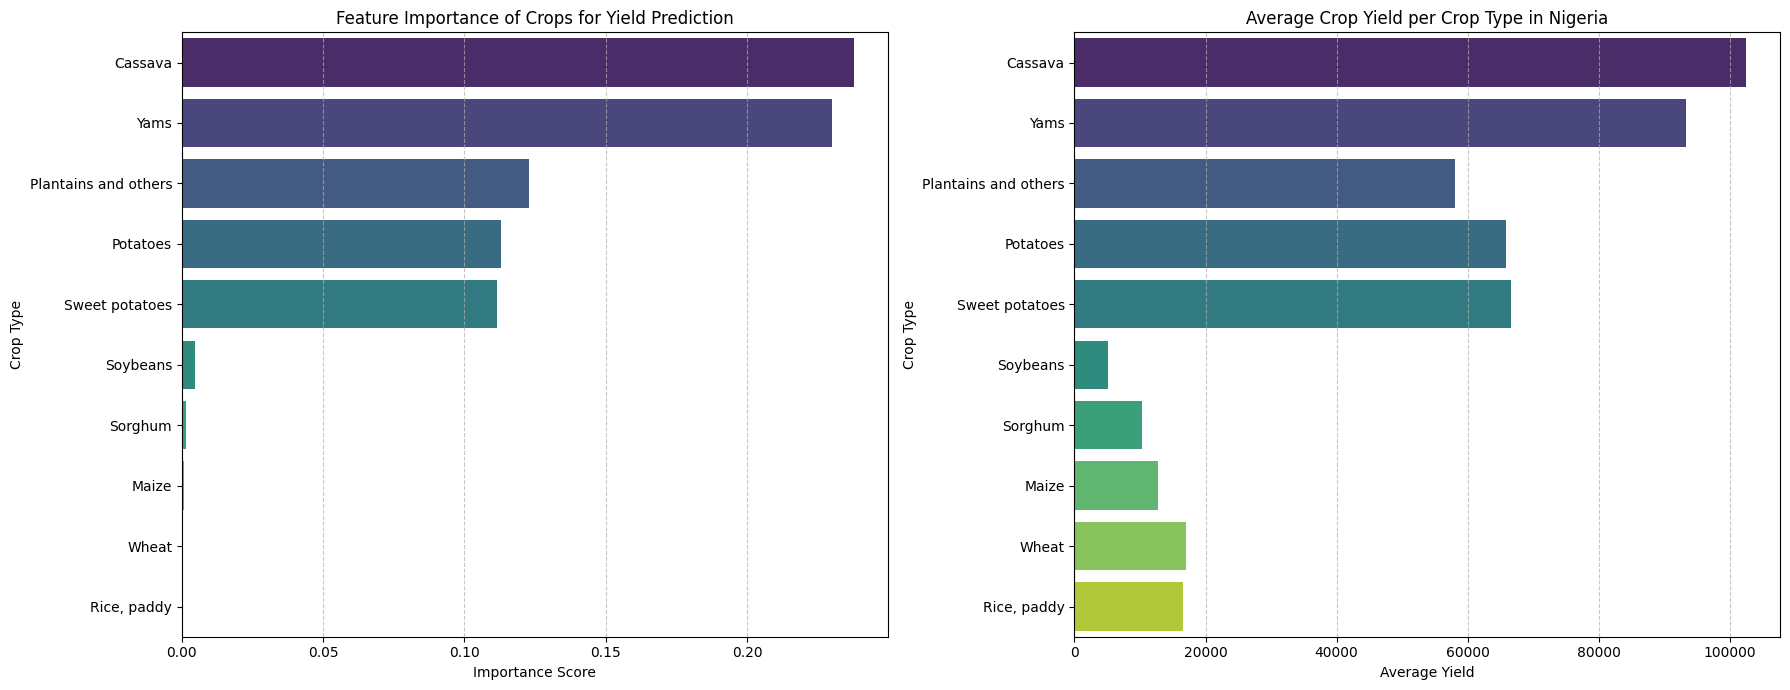

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter importance_df for crop-related features
crop_importance_df = importance_df[importance_df['Feature'].str.startswith('Crop_')].copy()
crop_importance_df['Crop'] = crop_importance_df['Feature'].str.replace('Crop_', '')

# Merge with average_yield_per_crop
comparison_df = pd.merge(crop_importance_df, average_yield_per_crop, on='Crop', how='inner')

# Sort by importance for consistent plotting
comparison_df = comparison_df.sort_values(by='Importance', ascending=False)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot Feature Importance
sns.barplot(ax=axes[0], x='Importance', y='Crop', data=comparison_df, palette='viridis', hue='Crop', legend=False)
axes[0].set_title('Feature Importance of Crops for Yield Prediction')
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('Crop Type')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Plot Average Crop Yield
sns.barplot(ax=axes[1], x='Yield', y='Crop', data=comparison_df, palette='viridis', hue='Crop', legend=False)
axes[1].set_title('Average Crop Yield per Crop Type in Nigeria')
axes[1].set_xlabel('Average Yield')
axes[1].set_ylabel('Crop Type')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Year and Crop to see trends for each crop type
yield_trends = nigeria_df.groupby(['Year', 'Crop'])['Yield'].mean().reset_index()

plt.figure(figsize=(14, 8))
sns.lineplot(x='Year', y='Yield', hue='Crop', data=yield_trends, marker='o')
plt.title('Crop Yield Trends in Nigeria Over the Years')
plt.xlabel('Year')
plt.ylabel('Average Yield')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Summary of Analysis

- **Data Loading & Cleaning**: Loaded yield, rainfall, pesticides, and temperature data. Cleaned column names, converted data types, and handled missing values by imputing means.
- **Data Merging**: Merged all datasets into a comprehensive `merged_df` based on 'Year' and 'Area', further cleaning and imputing any remaining missing values.
- **Data Preparation for Modeling**: Filtered the dataset for Nigeria (`nigeria_df`), defined features (`X`) and target (`y`), and applied one-hot encoding to the 'Crop' categorical feature.
- **Model Training & Evaluation**: Trained a `RandomForestRegressor` model to predict crop yield. The model achieved a high R-squared (R2) value, indicating good predictive performance, and we visualized actual vs. predicted yields.
- **Feature Importance Analysis**: Identified the most important features for predicting crop yield, with 'Crop_Cassava' and 'Crop_Yams' showing the highest importance.
- **Comparison of Feature Importance with Actual Yields**: Compared the feature importance of crops with their average actual yields in Nigeria, noting a strong correlation where high-importance crops also exhibited high average yields.
- **Crop Yield Trends (Nigeria)**: Visualized crop yield trends for various crops in Nigeria over the years using line plots and heatmaps.
- **Average Crop Yield in Nigeria**: Generated a bar chart displaying the average crop yield for each crop type specifically in Nigeria.
- **Correlation Analysis**: Explored the correlation between rainfall, temperature, and crop yield using a heatmap, which showed generally weak correlations between these environmental factors and yield in the overall dataset.

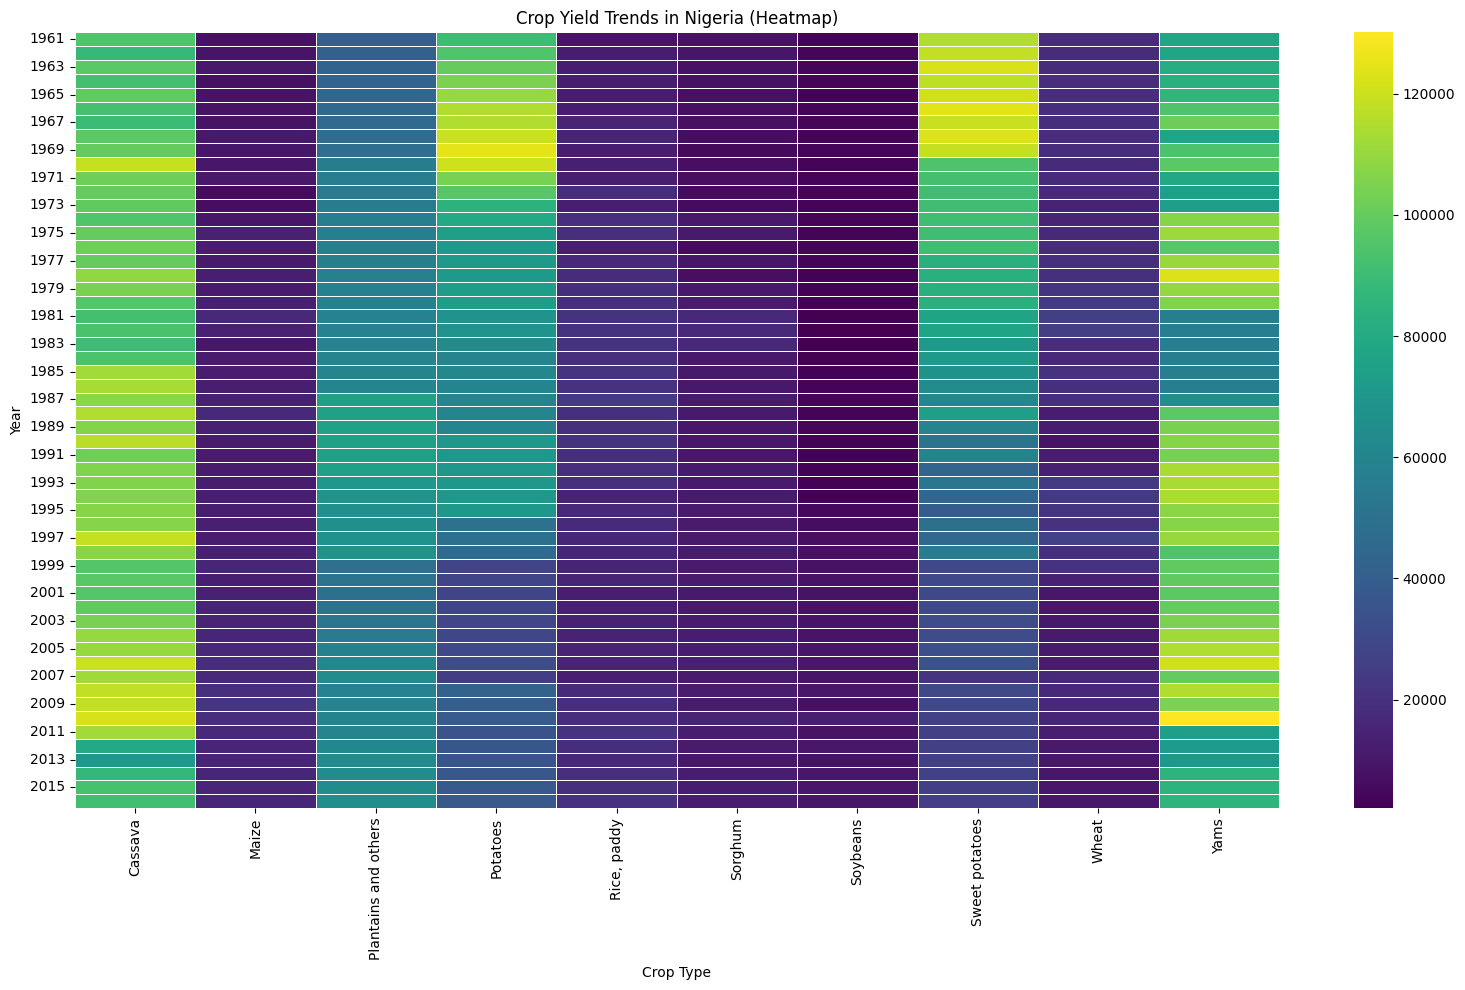

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot the yield_trends DataFrame for the heatmap
yield_pivot = yield_trends.pivot_table(index='Year', columns='Crop', values='Yield')

plt.figure(figsize=(16, 10))
sns.heatmap(yield_pivot, cmap='viridis', annot=False, fmt=".0f", linewidths=.5)
plt.title('Crop Yield Trends in Nigeria (Heatmap)')
plt.xlabel('Crop Type')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

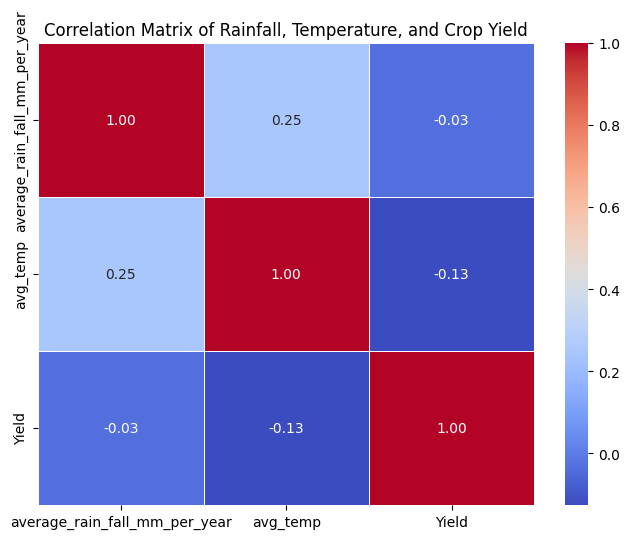

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the relevant columns for correlation analysis
correlation_data = merged_df[['average_rain_fall_mm_per_year', 'avg_temp', 'Yield']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Rainfall, Temperature, and Crop Yield')
plt.show()

/tmp/ipykernel_1349/788141833.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Yield', y='Crop', data=average_yield_per_crop, palette='viridis')


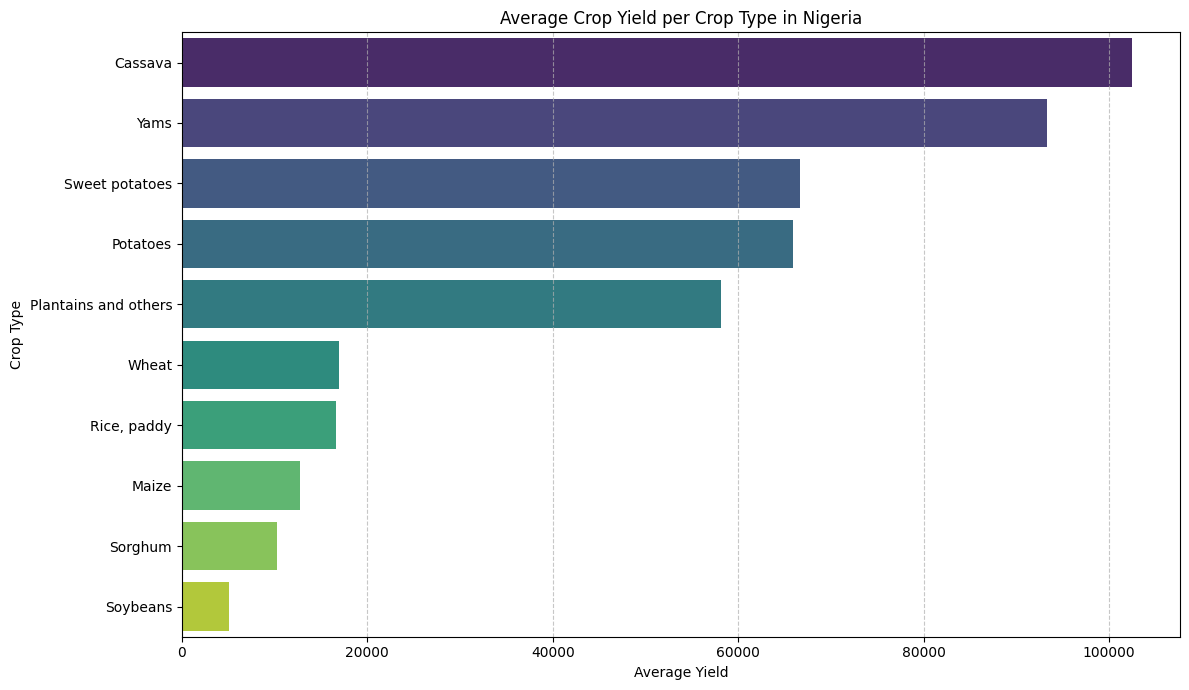

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average yield per crop in Nigeria
average_yield_per_crop = nigeria_df.groupby('Crop')['Yield'].mean().reset_index()

# Sort for better visualization
average_yield_per_crop = average_yield_per_crop.sort_values(by='Yield', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Yield', y='Crop', data=average_yield_per_crop, palette='viridis')
plt.title('Average Crop Yield per Crop Type in Nigeria')
plt.xlabel('Average Yield')
plt.ylabel('Crop Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()